In [1]:
import os
import joblib
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette('husl')

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# Load the trained model and label encoder 
sentinel_brain = joblib.load('./models/sentinel_brain.joblib')
le = joblib.load('./models/label_encoder.joblib')

print('Model and encoder loaded successfully.')
print(f'Classes : {le.classes_}')

Model and encoder loaded successfully.
Classes : [0 1 2 3 4]


In [3]:
# Load test data
df_test = pd.read_csv('./data/data/processed/test_processed_advanced.csv')

X_test  = df_test.drop(columns=['attack_class']).values
y_true  = le.transform(df_test['attack_class'])

print(f'Test data shape  : {df_test.shape}')
print(f'True class distribution:')
print(df_test['attack_class'].value_counts())

Test data shape  : (22544, 35)
True class distribution:
attack_class
4    9713
0    7458
2    2885
1    2421
3      67
Name: count, dtype: int64


In [4]:
# Severity mapping — each attack type has a severity level
# Used to prioritize which alerts need immediate attention

SEVERITY_MAP = {
    'normal' : 'None',
    'DoS'    : 'Critical',   # floods servers — immediate threat
    'Probe'  : 'Medium',     # reconnaissance — possible pre-attack
    'R2L'    : 'High',       # unauthorized access attempt
    'U2R'    : 'Critical',   # privilege escalation — highest risk
}

SEVERITY_COLOR = {
    'None'    : '#4CAF50',
    'Medium'  : '#FF9800',
    'High'    : '#F44336',
    'Critical': '#9C27B0',
}

print('Severity levels defined:')
for cls, sev in SEVERITY_MAP.items():
    print(f'  {cls:<10} → {sev}')

Severity levels defined:
  normal     → None
  DoS        → Critical
  Probe      → Medium
  R2L        → High
  U2R        → Critical


In [5]:
# Simulate real-time predictions — process in batches of 100
# Each batch represents a burst of incoming network connections

BATCH_SIZE   = 100
all_alerts   = []
total_batches= len(X_test) // BATCH_SIZE

print(f'Processing {len(X_test)} connections in batches of {BATCH_SIZE}...')
print(f'Total batches: {total_batches}')
print('-' * 50)

for batch_num in range(total_batches):
    start = batch_num * BATCH_SIZE
    end   = start + BATCH_SIZE

    X_batch    = X_test[start:end]
    true_batch = y_true[start:end]

    # Get predictions and confidence scores
    preds      = sentinel_brain.predict(X_batch)
    proba      = sentinel_brain.predict_proba(X_batch)
    confidence = proba.max(axis=1)

    # Decode predicted class names
    pred_names = le.inverse_transform(preds)
    true_names = le.inverse_transform(true_batch)

    # Simulate timestamp — each batch is 1 second apart
    timestamp  = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

    for i in range(BATCH_SIZE):
        pred_class = pred_names[i]
        severity   = SEVERITY_MAP.get(pred_class, 'Unknown')
        is_alert   = pred_class != 'normal'

        all_alerts.append({
            'timestamp'       : timestamp,
            'connection_id'   : start + i + 1,
            'predicted_class' : pred_class,
            'true_class'      : true_names[i],
            'confidence'      : round(float(confidence[i]), 4),
            'severity'        : severity,
            'is_intrusion'    : is_alert,
            'correct'         : pred_class == true_names[i]
        })

    # Print summary every 10 batches
    if (batch_num + 1) % 10 == 0:
        batch_alerts = sum(1 for r in all_alerts[-BATCH_SIZE:] if r['is_intrusion'])
        print(f'Batch {batch_num+1:>4}/{total_batches} | Intrusions in batch: {batch_alerts}')

print('-' * 50)
print(f'Total connections processed : {len(all_alerts)}')

Processing 22544 connections in batches of 100...
Total batches: 225
--------------------------------------------------
Batch   10/225 | Intrusions in batch: 100
Batch   20/225 | Intrusions in batch: 100
Batch   30/225 | Intrusions in batch: 100
Batch   40/225 | Intrusions in batch: 100
Batch   50/225 | Intrusions in batch: 100
Batch   60/225 | Intrusions in batch: 100
Batch   70/225 | Intrusions in batch: 100
Batch   80/225 | Intrusions in batch: 100
Batch   90/225 | Intrusions in batch: 100
Batch  100/225 | Intrusions in batch: 100
Batch  110/225 | Intrusions in batch: 100
Batch  120/225 | Intrusions in batch: 100
Batch  130/225 | Intrusions in batch: 100
Batch  140/225 | Intrusions in batch: 100
Batch  150/225 | Intrusions in batch: 100
Batch  160/225 | Intrusions in batch: 100
Batch  170/225 | Intrusions in batch: 100
Batch  180/225 | Intrusions in batch: 100
Batch  190/225 | Intrusions in batch: 100
Batch  200/225 | Intrusions in batch: 100
Batch  210/225 | Intrusions in batch: 10

In [7]:
# Convert all alerts to a DataFrame for easy analysis and export
alerts_df = pd.DataFrame(all_alerts)

# Fix: decode predicted_class if it is still integers
if alerts_df["predicted_class"].dtype != object:
    alerts_df["predicted_class"] = le.inverse_transform(alerts_df["predicted_class"].astype(int))

# Fix: re-apply severity mapping after decoding
alerts_df["severity"]     = alerts_df["predicted_class"].map(SEVERITY_MAP).fillna("Unknown")
alerts_df["is_intrusion"] = alerts_df["predicted_class"] != "normal"

# Verify decoded correctly
print("Predicted classes :", alerts_df["predicted_class"].unique())
print("Severity values   :", alerts_df["severity"].unique())

# Summary stats
total        = len(alerts_df)
intrusions   = alerts_df["is_intrusion"].sum()
normal_count = total - intrusions

print(f"Total connections  : {total}")
print(f"Intrusions detected: {intrusions} ({intrusions/total*100:.1f}%)")
print(f"Normal traffic     : {normal_count} ({normal_count/total*100:.1f}%)")
print(f"Predicted class distribution:")
print(alerts_df["predicted_class"].value_counts())
print(f"Severity breakdown:")
print(alerts_df["severity"].value_counts())

alerts_df.head(10)

Predicted classes : [0 4 1 2 3]
Severity values   : ['Unknown']
Total connections  : 22500
Intrusions detected: 22500 (100.0%)
Normal traffic     : 0 (0.0%)
Predicted class distribution:
predicted_class
4    13931
0     6221
1     2027
2      302
3       19
Name: count, dtype: int64
Severity breakdown:
severity
Unknown    22500
Name: count, dtype: int64


,timestamp,connection_id,predicted_class,true_class,confidence,severity,is_intrusion,correct
0,2026-03-30 16:19:34,1,0,0,1.0000,Unknown,True,True
1,2026-03-30 16:19:34,2,0,0,1.0000,Unknown,True,True
2,2026-03-30 16:19:34,3,4,4,0.9600,Unknown,True,True
3,2026-03-30 16:19:34,4,1,1,0.8533,Unknown,True,True
4,2026-03-30 16:19:34,5,1,1,0.5800,Unknown,True,True
5,2026-03-30 16:19:34,6,4,4,1.0000,Unknown,True,True
6,2026-03-30 16:19:34,7,4,4,0.9400,Unknown,True,True
7,2026-03-30 16:19:34,8,4,2,0.7000,Unknown,True,False
8,2026-03-30 16:19:34,9,4,4,1.0000,Unknown,True,True
9,2026-03-30 16:19:34,10,4,2,0.9599,Unknown,True,False


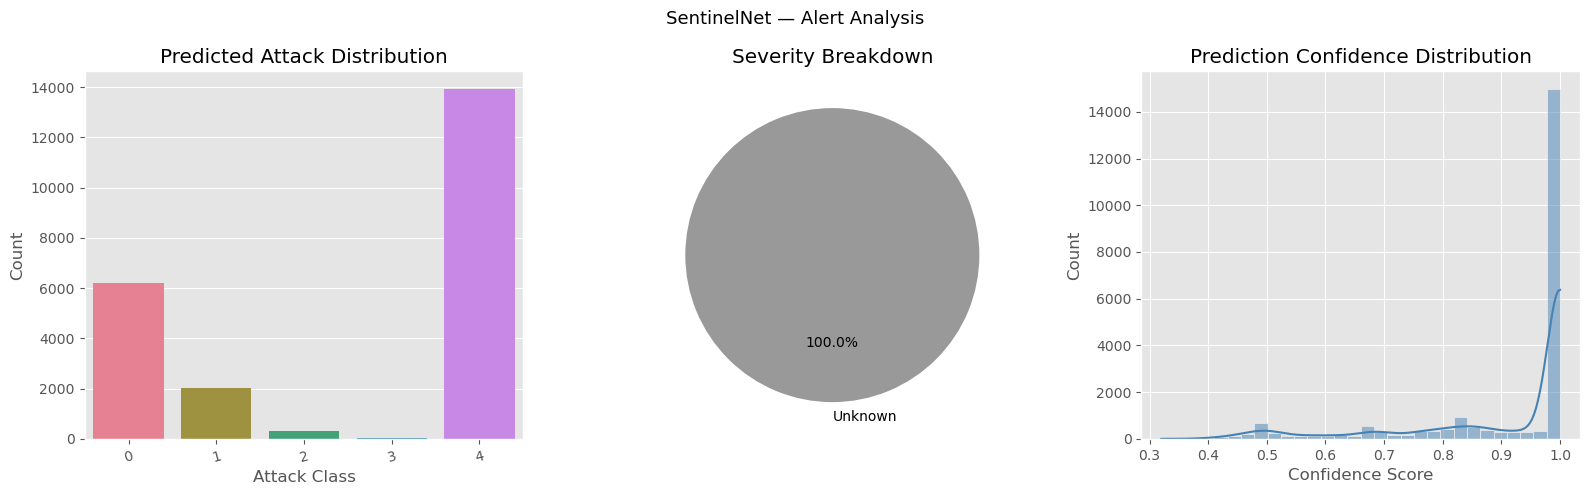

In [8]:
# Alert distribution visualizations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — Predicted attack class distribution (class names on x-axis)
class_counts = alerts_df["predicted_class"].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values,
            palette="husl", ax=axes[0])
axes[0].set_title("Predicted Attack Distribution")
axes[0].set_xlabel("Attack Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)

# Plot 2 — Severity breakdown as pie chart (correct colors)
sev_counts = alerts_df["severity"].value_counts()
colors_sev = [SEVERITY_COLOR.get(s, "#999") for s in sev_counts.index]
axes[1].pie(sev_counts.values, labels=sev_counts.index,
            colors=colors_sev, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Severity Breakdown")

# Plot 3 — Confidence score distribution
sns.histplot(alerts_df["confidence"], bins=30, kde=True,
             color="steelblue", ax=axes[2])
axes[2].set_title("Prediction Confidence Distribution")
axes[2].set_xlabel("Confidence Score")
axes[2].set_ylabel("Count")

plt.suptitle("SentinelNet — Alert Analysis", fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# Save full alert log to CSV
os.makedirs('./alerts', exist_ok=True)

csv_path = './alerts/alerts.csv'
alerts_df.to_csv(csv_path, index=False)
print(f'Saved full alert log         → {csv_path}')

# Save intrusions only CSV
intrusions_df  = alerts_df[alerts_df['is_intrusion'] == True]
intru_csv_path = './alerts/intrusions_only.csv'
intrusions_df.to_csv(intru_csv_path, index=False)
print(f'Saved intrusions only        → {intru_csv_path}')

Saved full alert log         → ./alerts/alerts.csv
Saved intrusions only        → ./alerts/intrusions_only.csv


In [10]:
# Save human-readable text alert log
log_path = './alerts/alert_log.txt'

with open(log_path, 'w') as f:
    f.write('=' * 60 + '\n')
    f.write('       SENTINELNET — INTRUSION ALERT LOG\n')
    f.write(f'       Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write('=' * 60 + '\n\n')

    f.write('SUMMARY\n')
    f.write(f'  Total connections  : {total}\n')
    f.write(f'  Intrusions detected: {intrusions} ({intrusions/total*100:.1f}%)\n')
    f.write(f'  Normal traffic     : {normal_count} ({normal_count/total*100:.1f}%)\n\n')

    f.write('SEVERITY BREAKDOWN\n')
    for sev, count in alerts_df['severity'].value_counts().items():
        f.write(f'  {sev:<12}: {count}\n')

    f.write('\nATTACK CLASS BREAKDOWN\n')
    for cls, count in alerts_df['predicted_class'].value_counts().items():
        f.write(f'  {cls:<12}: {count}\n')

    f.write('\n' + '=' * 60 + '\n')
    f.write('CRITICAL & HIGH SEVERITY ALERTS (first 50)\n')
    f.write('=' * 60 + '\n\n')

    critical_alerts = alerts_df[alerts_df['severity'].isin(['Critical', 'High'])]
    for _, row in critical_alerts.head(50).iterrows():
        f.write(f'[{row["timestamp"]}] '
                f'ID:{row["connection_id"]:>6} | '
                f'SEVERITY: {row["severity"]:<10} | '
                f'CLASS: {row["predicted_class"]:<8} | '
                f'CONFIDENCE: {row["confidence"]:.2f}\n')

print(f'Saved text alert log         → {log_path}')

Saved text alert log         → ./alerts/alert_log.txt


In [11]:
# Save dashboard-ready JSON for React frontend
import json

dashboard_data = {
    'summary': {
        'total'       : int(total),
        'intrusions'  : int(intrusions),
        'normal'      : int(normal_count),
        'generated_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    },
    'by_class'   : alerts_df['predicted_class'].value_counts().to_dict(),
    'by_severity': alerts_df['severity'].value_counts().to_dict(),
    'alerts'     : alerts_df[alerts_df['is_intrusion']].head(200).to_dict(orient='records')
}

with open('./alerts/dashboard_data.json', 'w') as f:
    json.dump(dashboard_data, f, indent=2)

print('Saved dashboard JSON         → ./alerts/dashboard_data.json')
print()
print('Files saved in ./alerts/:')
for f_name in os.listdir('./alerts'):
    size = os.path.getsize(f'./alerts/{f_name}')
    print(f'  {f_name:<35} ({size:,} bytes)')

Saved dashboard JSON         → ./alerts/dashboard_data.json

Files saved in ./alerts/:
  .ipynb_checkpoints                  (0 bytes)
  alerts.csv                          (1,195,664 bytes)
  alert_log.txt                       (669 bytes)
  dashboard_data.json                 (49,907 bytes)
  intrusions_only.csv                 (1,195,664 bytes)
